# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

#### Who (The Decision-Maker or Stakeholder)

- Real estate investors looking to buy properties in Austin, TX for rental or resale.
- Homeowners considering listing their property on Airbnb to generate income.
- Real estate agents and analysts looking for insights into market trends.
- Urban planners and policymakers interested in understanding short-term rental impacts.

#### What (The Decision to Be Made)

- Whether to invest in a property for short-term rental (Airbnb) or long-term resale.
- Identifying undervalued properties with high potential for appreciation or rental income.
- Predicting future property values based on features like size, location, and historical price trends.
- Determining key factors that influence Airbnb pricing and occupancy rates.
- Comparing Austin’s real estate market to national trends to identify investment opportunities.

#### How (The Data and Techniques Used to Support the Decision)
- Supervised Learning: Using regression models to predict property prices and potential Airbnb income.
- Unsupervised Learning: Applying clustering techniques (e.g., K-means) to group similar properties and identify patterns.
- Feature Engineering: Extracting insights from amenities, location, and text data (descriptions, reviews).
- Geospatial Analysis: Mapping property values and rental demand across different Austin neighborhoods.
- Comparative Analysis: Cross-referencing traditional home sales with Airbnb profitability metrics to determine the best investment strategy.

# 3. Homework - work with your own data

In [10]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

In [1]:
import pandas as pd

austin_df = pd.read_csv("austinHousingData.csv")
print(austin_df.head())


         zpid          city          streetAddress  zipcode  \
0   111373431  pflugerville   14424 Lake Victor Dr    78660   
1   120900430  pflugerville     1104 Strickling Dr    78660   
2  2084491383  pflugerville    1408 Fort Dessau Rd    78660   
3   120901374  pflugerville     1025 Strickling Dr    78660   
4    60134862  pflugerville  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  ...  numOfMiddleSchools  \
0             1.98             2            True  ...                   1  

In [2]:
print(austin_df.info())
print(austin_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15171 entries, 0 to 15170
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   zpid                        15171 non-null  int64  
 1   city                        15171 non-null  object 
 2   streetAddress               15171 non-null  object 
 3   zipcode                     15171 non-null  int64  
 4   description                 15169 non-null  object 
 5   latitude                    15171 non-null  float64
 6   longitude                   15171 non-null  float64
 7   propertyTaxRate             15171 non-null  float64
 8   garageSpaces                15171 non-null  int64  
 9   hasAssociation              15171 non-null  bool   
 10  hasCooling                  15171 non-null  bool   
 11  hasGarage                   15171 non-null  bool   
 12  hasHeating                  15171 non-null  bool   
 13  hasSpa                      151

In [3]:
print(f"Austin dataset duplicate rows: {austin_df.duplicated().sum()}")
austin_df = austin_df.drop_duplicates()

Austin dataset duplicate rows: 0


In [4]:
missing_values = austin_df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Since 'description' column has 2 missing values, we can fill those with "No description"
austin_df['description'] = austin_df['description'].fillna("No description")


Missing values in each column:
zpid                          0
city                          0
streetAddress                 0
zipcode                       0
description                   2
latitude                      0
longitude                     0
propertyTaxRate               0
garageSpaces                  0
hasAssociation                0
hasCooling                    0
hasGarage                     0
hasHeating                    0
hasSpa                        0
hasView                       0
homeType                      0
parkingSpaces                 0
yearBuilt                     0
latestPrice                   0
numPriceChanges               0
latest_saledate               0
latest_salemonth              0
latest_saleyear               0
latestPriceSource             0
numOfPhotos                   0
numOfAccessibilityFeatures    0
numOfAppliances               0
numOfParkingFeatures          0
numOfPatioAndPorchFeatures    0
numOfSecurityFeatures         0
numOfWate

In [5]:
# Checking for inconsistent values like negative prices or incorrect year built
inconsistent_data_price = austin_df[austin_df['latestPrice'] <= 0]
print("Inconsistent data (prices <= 0):")
print(inconsistent_data_price)

inconsistent_data_year = austin_df[austin_df['yearBuilt'] < 1900]
print("Inconsistent data (homes built before 1900):")
print(inconsistent_data_year)

Inconsistent data (prices <= 0):
Empty DataFrame
Columns: [zpid, city, streetAddress, zipcode, description, latitude, longitude, propertyTaxRate, garageSpaces, hasAssociation, hasCooling, hasGarage, hasHeating, hasSpa, hasView, homeType, parkingSpaces, yearBuilt, latestPrice, numPriceChanges, latest_saledate, latest_salemonth, latest_saleyear, latestPriceSource, numOfPhotos, numOfAccessibilityFeatures, numOfAppliances, numOfParkingFeatures, numOfPatioAndPorchFeatures, numOfSecurityFeatures, numOfWaterfrontFeatures, numOfWindowFeatures, numOfCommunityFeatures, lotSizeSqFt, livingAreaSqFt, numOfPrimarySchools, numOfElementarySchools, numOfMiddleSchools, numOfHighSchools, avgSchoolDistance, avgSchoolRating, avgSchoolSize, MedianStudentsPerTeacher, numOfBathrooms, numOfBedrooms, numOfStories, homeImage]
Index: []

[0 rows x 47 columns]
Inconsistent data (homes built before 1900):
Empty DataFrame
Columns: [zpid, city, streetAddress, zipcode, description, latitude, longitude, propertyTaxRate

In [6]:
# One-hot encode the categorical variables 'city' and 'homeType'
austin_df_encoded = pd.get_dummies(austin_df, columns=['city', 'homeType'], drop_first=True)
print(austin_df_encoded.head())

         zpid          streetAddress  zipcode  \
0   111373431   14424 Lake Victor Dr    78660   
1   120900430     1104 Strickling Dr    78660   
2  2084491383    1408 Fort Dessau Rd    78660   
3   120901374     1025 Strickling Dr    78660   
4    60134862  15005 Donna Jane Loop    78660   

                                         description   latitude  longitude  \
0  14424 Lake Victor Dr, Pflugerville, TX 78660 i...  30.430632 -97.663078   
1  Absolutely GORGEOUS 4 Bedroom home with 2 full...  30.432673 -97.661697   
2  Under construction - estimated completion in A...  30.409748 -97.639771   
3  Absolutely darling one story home in charming ...  30.432112 -97.661659   
4  Brimming with appeal & warm livability! Sleek ...  30.437368 -97.656860   

   propertyTaxRate  garageSpaces  hasAssociation  hasCooling  ...  \
0             1.98             2            True        True  ...   
1             1.98             2            True        True  ...   
2             1.98           

In [7]:
# Checking for class imbalance in categorical columns
city_counts = austin_df['city'].value_counts()
home_type_counts = austin_df['homeType'].value_counts()

print("Class imbalance in 'city':")
print(city_counts)

print("\nClass imbalance in 'homeType':")
print(home_type_counts)

Class imbalance in 'city':
city
austin              15020
del valle              86
pflugerville           36
driftwood              12
manor                   6
dripping springs        5
manchaca                3
west lake hills         2
road                    1
Name: count, dtype: int64

Class imbalance in 'homeType':
homeType
Single Family            14241
Condo                      470
Townhouse                  174
Multiple Occupancy          96
Vacant Land                 83
Residential                 37
Apartment                   37
Mobile / Manufactured       17
MultiFamily                 10
Other                        6
Name: count, dtype: int64


# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

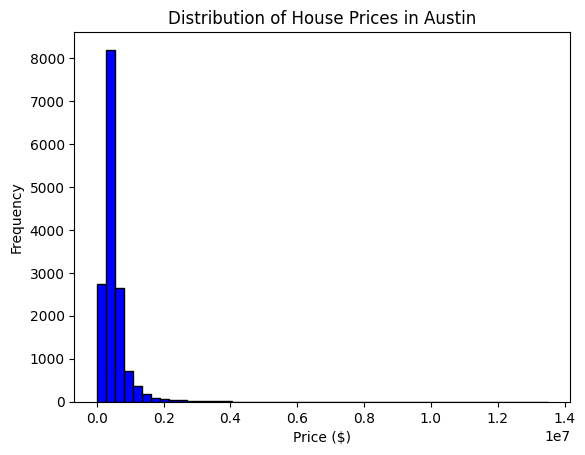

In [8]:
import matplotlib.pyplot as plt

# Plot histogram for the house prices
plt.hist(austin_df['latestPrice'], bins=50, color='blue', edgecolor='black')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices in Austin')
plt.show()

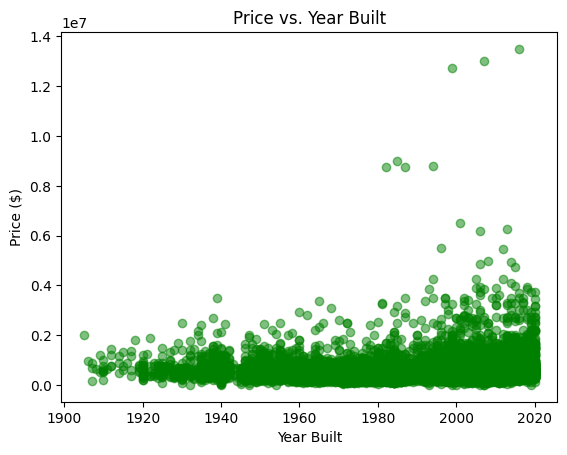

In [9]:
# Scatter plot for price vs. year built
plt.scatter(austin_df['yearBuilt'], austin_df['latestPrice'], alpha=0.5, color='green')
plt.xlabel('Year Built')
plt.ylabel('Price ($)')
plt.title('Price vs. Year Built')
plt.show()